# Initialization in Deep Neural Networks

---

## 1. Problems Caused by Bad Initialization

Initialization determines how signals (forward pass) and gradients (backward pass) propagate through depth. Poor scaling at initialization leads to systematic training issues even before meaningful learning begins.

### Main Problems and Their Consequences

- **Vanishing activations (forward pass)**  
  Activations shrink as depth increases, causing later layers to receive near-zero signal and reducing the model’s expressive power.

- **Exploding activations (forward pass)**  
  Activations grow uncontrollably across layers, leading to numerical instability and saturation of nonlinearities.

- **Vanishing gradients (backward pass)**  
  Gradients become extremely small in early layers, making learning very slow or effectively stopping parameter updates.

- **Exploding gradients (backward pass)**  
  Gradients grow exponentially during backpropagation, causing unstable updates and possible divergence.

- **Saturation of nonlinearities (e.g., sigmoid, tanh)**  
  Neurons operate in flat regions of the activation function where derivatives are close to zero, severely reducing gradient flow.

- **Dead neurons (ReLU networks)**  
  A large fraction of neurons output zero and contribute little to learning for many inputs.

All these issues share a common root cause: poor control of variance propagation across layers.

---

## 2. Variance Propagation Through a Layer

Consider a layer defined by:
$$
z^{(\ell)} = W^{(\ell)} a^{(\ell-1)}, 
\qquad
a^{(\ell)} = \phi\big(z^{(\ell)}\big).
$$

Assume:
- inputs x are zero-mean with variance $\sigma_x^2$

- weights are zero-mean with variance $\sigma_W^2$

- input size is $n$

Then, approximately:
$$
\operatorname{Var}(z^{(\ell)}) \approx n \cdot \sigma_x^2 \cdot \sigma_W^2.
$$

A well-scaled initialization aims to keep:
$$
\operatorname{Var}(a^{(\ell)}) \approx \operatorname{Var}(a^{(\ell-1)}),
$$
so that the signal neither explodes nor vanishes as depth increases.

---

## 3. Xavier Initialization

### Definition
For a layer with input size $n$ and output size $m$:
$$
\operatorname{Var}(W) \approx \frac{2}{n + m},
$$
and in many practical settings this is simplified to:
$$
\operatorname{Var}(W) \approx \frac{1}{n}.
$$

### Intuition
Xavier initialization is designed for symmetric and smooth activations such as:
- $\tanh$
- sigmoid (near the linear regime)

These activations do not strongly truncate the signal around zero, so preserving the pre-activation variance is usually sufficient to maintain stability.

### Effect on Output Variance
With this scaling:
- the pre-activation variance stays close to the input variance
- the activation variance remains in a stable range
- gradients are less likely to systematically shrink or explode in deep networks

---

## 4. He Initialization

### Definition
For ReLU and ReLU-like activations:
$$
\operatorname{Var}(W) = \frac{2}{n}.
$$

### Why ReLU Requires Different Scaling
ReLU is defined as:
$$
\text{ReLU}(z) = \max(0, z).
$$

If $z$ is approximately zero-mean, about half of the pre-activations are negative and get mapped to zero. This truncation reduces the output variance in half compared to the input variance, reducing input features signals.

### Variance Compensation Mechanism
He initialization increases the weight variance so that the variance lost due to ReLU sparsity is statistically compensated. As a result:
- many activations can still be zero
- but the overall variance of the layer output remains roughly stable

This preserves the expected signal scale across layers rather than preventing neurons from being inactive.

---

## 5. How Xavier and He Scale the Output

- **Xavier initialization**  
  Assumes activations are symmetric and near-linear around zero.  
  It keeps the signal scale stable without accounting for strong truncation effects.

- **He initialization**  
  Specifically accounts for the fact that ReLU discards negative values.  
  The larger weight variance offsets the reduction in variance caused by zeroing a large portion of the activations.

Key intuition:
$$
\text{If the activation reduces variance} \;\Rightarrow\; \text{increase weight variance to preserve signal scale}
$$

---

## 6. Why Preserving Variance is Crucial in Large Networks

In deep networks, each layer slightly rescales the signal, and these small changes accumulate multiplicatively with depth.

If variance systematically decreases across layers:
- activations collapse toward zero
- representations lose information
- gradients tend to vanish

If variance systematically increases:
- activations explode
- nonlinearities saturate
- gradients become unstable

Preserving variance across layers ensures:
- stable forward signal propagation
- stable gradient magnitudes during backpropagation
- efficient optimization
- trainability of deep architectures

Ideally, the network operates in a regime where the effective scaling factor of variance across layers is close to $1$, preventing both exponential decay and exponential growth of signals and gradients.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

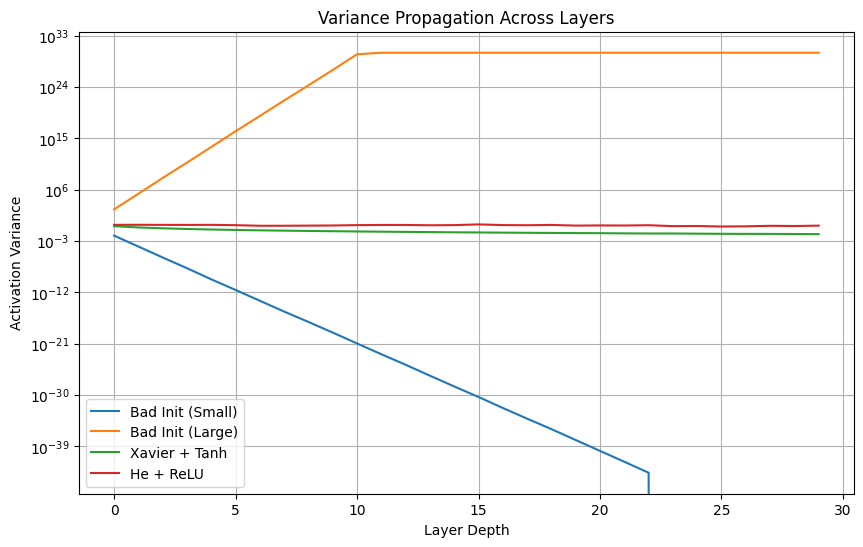

In [21]:
def init_weights(layer, mode="xavier"):
    if isinstance(layer, nn.Linear):
        if mode == "xavier":
            nn.init.xavier_normal_(layer.weight)
        elif mode == "he":
            nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
        elif mode == "bad_small":
            nn.init.normal_(layer.weight, mean=0.0, std=0.01)
        elif mode == "bad_large":
            nn.init.normal_(layer.weight, mean=0.0, std=2.0)
        
        nn.init.zeros_(layer.bias)

class DeepMLP(nn.Module):
    def __init__(self, depth=20, width=256, activation="relu"):
        super().__init__()
        
        layers = []
        act = nn.ReLU() if activation == "relu" else nn.Tanh()
        
        for _ in range(depth):
            layers.append(nn.Linear(width, width))
            layers.append(act)
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        activations = []

        for layer in self.net:
            x = layer(x)
            if isinstance(layer, (nn.ReLU, nn.Tanh)):
                activations.append(x)
        
        return activations
    
def measure_variance(depth=20, width=256, init="xavier", activation="relu", clip=1e30):
    model = DeepMLP(depth=depth, width=width, activation=activation)
    model.apply(lambda m: init_weights(m, mode=init))
    
    x = torch.randn(1024, width)
    activations = model(x)
    
    variances = []
    for a in activations:
        v = a.var()
        v = torch.nan_to_num(v, nan=clip, posinf=clip, neginf=0.0)
        v = torch.clamp(v, max=clip)
        variances.append(v.item())
        
    return variances

depth = 30
configs = [
    ("bad_small", "relu", "Bad Init (Small)"),
    ("bad_large", "relu", "Bad Init (Large)"),
    ("xavier", "tanh", "Xavier + Tanh"),
    ("he", "relu", "He + ReLU"),
]

plt.figure(figsize=(10, 6))

for init, act, label in configs:
    vars_layers = measure_variance(depth=depth, init=init, activation=act, clip=1e30)
    plt.plot(vars_layers, label=label)
    
plt.xlabel("Layer Depth")
plt.ylabel("Activation Variance")
plt.title("Variance Propagation Across Layers")
plt.legend()
plt.yscale("log")
plt.grid(True)
plt.show()

In [13]:
configs

[('bad_small', 'relu', 'Bad Init (Small)'),
 ('bad_large', 'relu', 'Bad Init (Large)'),
 ('xavier', 'tanh', 'Xavier + Tanh'),
 ('he', 'relu', 'He + ReLU')]

In [ ]:
the logic u used dont work with tensors

clip=1e6
x = 1.000000009
x = clip
x

1000000.0